In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee
from scipy.special import logsumexp
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.lines as mlines
import csv
import emcee
from multiprocessing import Pool, cpu_count

In [7]:
def get_limiti_prior(observed_freqs):

    f_min = 66
    f_max = 1568

    q_min = 0.1
    q_max = 1

    log_sigma_min = np.log(0.1)
    log_sigma_max = np.log(100)

    log_uniform = -np.log(np.max(observed_freqs) - np.min(observed_freqs))

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform, q_min, q_max


# prior uniforme con 1/ns
def compute_uniform_prior(ns):
    log_prior = -np.log(ns)
    return log_prior



In [8]:

def log_prob_emcee(theta, peak_freqs, f_min, f_max, log_sigma_min, log_sigma_max, log_uniform, q_min, q_max, P_n_log, ns_indices):
    f0, log_sigma, q = theta

    if not (f_min < f0 < f_max and log_sigma_min < log_sigma < log_sigma_max and q_min < q < q_max):
        return -np.inf

    if q <= 0.0 or q >= 1.0:
        return -np.inf

    sigma = np.exp(log_sigma)

    fk_col = peak_freqs[:, np.newaxis]
    
    log_gaussians = -0.5 * ((fk_col - ns_indices * f0) / sigma)**2 - log_sigma - 0.5 * np.log(2 * np.pi)

    log_p_harmonics = logsumexp(log_gaussians + P_n_log, axis=1)
    
    log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + log_uniform)

    total_log_likelihood = np.sum(log_p_total)

    if np.isnan(total_log_likelihood):
        return -np.inf

    return total_log_likelihood


def get_f0_bayesian_emcee(peak_freqs, peak_mags, id_nota):
    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform, q_min, q_max = get_limiti_prior(peak_freqs)
    ns = len(peak_freqs)
    P_n_log = compute_uniform_prior(ns)
    ns_indices = np.arange(1, ns + 1)
    
    args = (peak_freqs, f_min, f_max, log_sigma_min, log_sigma_max, log_uniform, q_min, q_max, P_n_log, ns_indices)

    f_start = np.clip(float(peak_freqs[0]), f_min + 1.0, f_max - 1.0)
    sigma_start = np.clip(np.log(0.1 * f_start), log_sigma_min + 0.1, log_sigma_max - 0.1)
    q_start = np.clip(0.8, q_min + 0.05, q_max - 0.05)
    
    initial_theta = np.array([f_start, sigma_start, q_start])

    ndim = 3          
    nwalkers = 32      
    nsteps = 200       

    pos = []
    spreads = np.array([2.0, 0.5, 0.05]) 
    
    while len(pos) < nwalkers:
        candidato = initial_theta + spreads * np.random.randn(ndim)
        # Verifica di validità stretta
        if (f_min < candidato[0] < f_max) and \
           (log_sigma_min < candidato[1] < log_sigma_max) and \
           (q_min < candidato[2] < q_max):
            pos.append(candidato)
            
    pos = np.array(pos)

    cartella_salvataggio = "catene_emcee"
    os.makedirs(cartella_salvataggio, exist_ok=True)
    
    # Costruisci il percorso del file h5 (es: "catene_emcee/catene_Nota_1.h5")
    percorso_file = os.path.join(cartella_salvataggio, f"catene_{id_nota}.h5")
    
    # Inizializza il backend di emcee
    backend = emcee.backends.HDFBackend(percorso_file)
    # IMPORTANTE: Resetta il file se esisteva già un'esecuzione precedente con lo stesso nome
    backend.reset(nwalkers, ndim)

    # Esecuzione MCMC parallelizzata
    num_cores = cpu_count()
    with Pool(processes=num_cores) as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_emcee, args=args, pool=pool)
        sampler.run_mcmc(pos, nsteps, progress=False)

    tau = sampler.get_autocorr_time(tol=0)
    print(f"Autocorrelation times: {tau}")

    discard_steps = 100
    flat_samples = sampler.get_chain(discard=discard_steps, thin=1, flat=True)
    flat_log_prob = sampler.get_log_prob(discard=discard_steps, thin=1, flat=True)


    map_index = np.argmax(flat_log_prob)
    f0_map, log_sigma_map, q_map = flat_samples[map_index]

    print(f"MCMC MAP -> F0: {f0_map:.2f}Hz, Sigma: {np.exp(log_sigma_map):.5f}Hz, q: {q_map:.8f}")

    return f0_map, q_map

In [9]:
base_dir = "dati_processati"
peak_file = "spettri_peaks.json"

filepath = os.path.join(base_dir, peak_file)

with open(filepath, 'r') as f:
    peaks_dict = json.load(f)


In [10]:

f0_results = {}
bayesian_q_results = {}
for sample, data in peaks_dict.items():
    print(f"Processing {sample}...")
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])

    bayesian_map_result = get_f0_bayesian_emcee(freqs, mags, id_nota=sample)
    if bayesian_map_result is None:
        bayesian_map_f0 = None
        bayesian_map_q = None
    else:
        bayesian_map_f0, bayesian_map_q = bayesian_map_result

    f0_results[sample] = {
        'bayesian_emcee': bayesian_map_f0
    }
    bayesian_q_results[sample] = bayesian_map_q


Processing Nota_1...
Autocorrelation times: [15.98638159 24.4617704  21.58762132]
MCMC MAP -> F0: 1563.26Hz, Sigma: 1.50981Hz, q: 0.99823196
Processing Nota_2...
Autocorrelation times: [17.45505256 25.20661499 14.96584049]
MCMC MAP -> F0: 1481.88Hz, Sigma: 0.35722Hz, q: 0.87810639
Processing Nota_3...
Autocorrelation times: [15.43641134 25.76259769 14.90753767]
MCMC MAP -> F0: 330.59Hz, Sigma: 0.42042Hz, q: 0.76872605
Processing Nota_4...
Autocorrelation times: [16.74430397 24.59947742 21.15983169]
MCMC MAP -> F0: 174.17Hz, Sigma: 0.58063Hz, q: 0.92660873
Processing Nota_5...
Autocorrelation times: [17.44836782 26.97850754 17.51185605]
MCMC MAP -> F0: 220.84Hz, Sigma: 0.36222Hz, q: 0.83793033
Processing Nota_6...
Autocorrelation times: [14.54084739 24.93857539 20.2821365 ]
MCMC MAP -> F0: 467.25Hz, Sigma: 0.43632Hz, q: 0.99766646
Processing Nota_7...
Autocorrelation times: [11.73352217 25.51138991 21.59331167]
MCMC MAP -> F0: 175.09Hz, Sigma: 0.34587Hz, q: 0.99507113
Processing Nota_8.

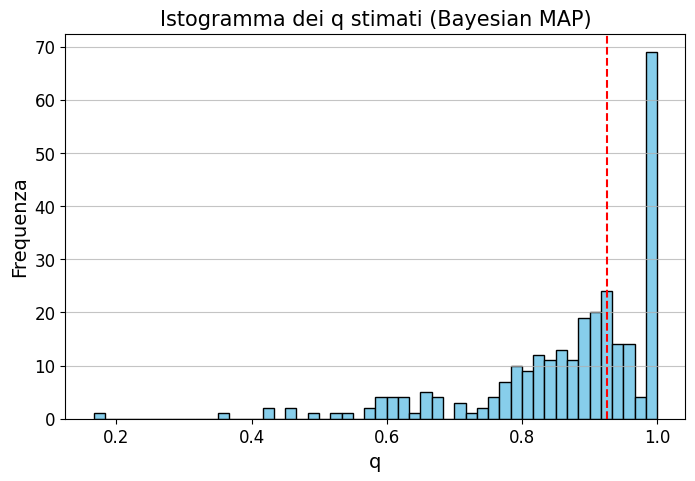

In [18]:
plt.rcParams.update({
    'font.size': 12,          # Dimensione base per tutto
    'axes.titlesize': 15,     # Titolo del grafico
    'axes.labelsize': 14,     # Etichette X e Y
    'xtick.labelsize': 12,    # Numeretti asse X
    'ytick.labelsize': 12,    # Numeretti asse Y
    'legend.fontsize': 12
})

# istogramma delle q_map stimate con il metodo bayesiano
bayesian_qs = [q for q in bayesian_q_results.values() if q is not None]
plt.figure(figsize=(8, 5))
plt.hist(bayesian_qs, bins=50, color='skyblue', edgecolor='black')

plt.axvline(0.925, color='red', linestyle='--', label='q = 0.8')

plt.title('Istogramma dei q stimati (Bayesian MAP)')
plt.xlabel('q')
plt.ylabel('Frequenza')
plt.grid(axis='y', alpha=0.75)
plt.savefig("istogramma_q_bayes_emcee.pdf")
plt.show()


Frequenze delle note:
  DO#1: 34.64 Hz
  DO#2: 69.29 Hz
  DO#3: 138.58 Hz
  DO#4: 277.16 Hz
  DO#5: 554.31 Hz
  DO#6: 1108.62 Hz
  DO1: 32.70 Hz
  DO2: 65.40 Hz
  DO3: 130.80 Hz
  DO4: 261.60 Hz
  DO5: 523.20 Hz
  DO6: 1046.40 Hz
  FA#1: 46.24 Hz
  FA#2: 92.49 Hz
  FA#3: 184.98 Hz
  FA#4: 369.96 Hz
  FA#5: 739.92 Hz
  FA#6: 1479.83 Hz
  FA1: 43.65 Hz
  FA2: 87.30 Hz
  FA3: 174.60 Hz
  FA4: 349.19 Hz
  FA5: 698.39 Hz
  FA6: 1396.78 Hz
  LA#1: 58.26 Hz
  LA#2: 116.53 Hz
  LA#3: 233.06 Hz
  LA#4: 466.12 Hz
  LA#5: 932.24 Hz
  LA#6: 1864.47 Hz
  LA1: 54.99 Hz
  LA2: 109.99 Hz
  LA3: 219.98 Hz
  LA4: 439.96 Hz
  LA5: 879.91 Hz
  LA6: 1759.83 Hz
  MI1: 41.20 Hz
  MI2: 82.40 Hz
  MI3: 164.80 Hz
  MI4: 329.60 Hz
  MI5: 659.19 Hz
  MI6: 1318.38 Hz
  RE#1: 38.89 Hz
  RE#2: 77.77 Hz
  RE#3: 155.55 Hz
  RE#4: 311.10 Hz
  RE#5: 622.19 Hz
  RE#6: 1244.39 Hz
  RE1: 36.70 Hz
  RE2: 73.41 Hz
  RE3: 146.82 Hz
  RE4: 293.64 Hz
  RE5: 587.27 Hz
  RE6: 1174.54 Hz
  SI1: 61.73 Hz
  SI2: 123.46 Hz
  SI3: 246

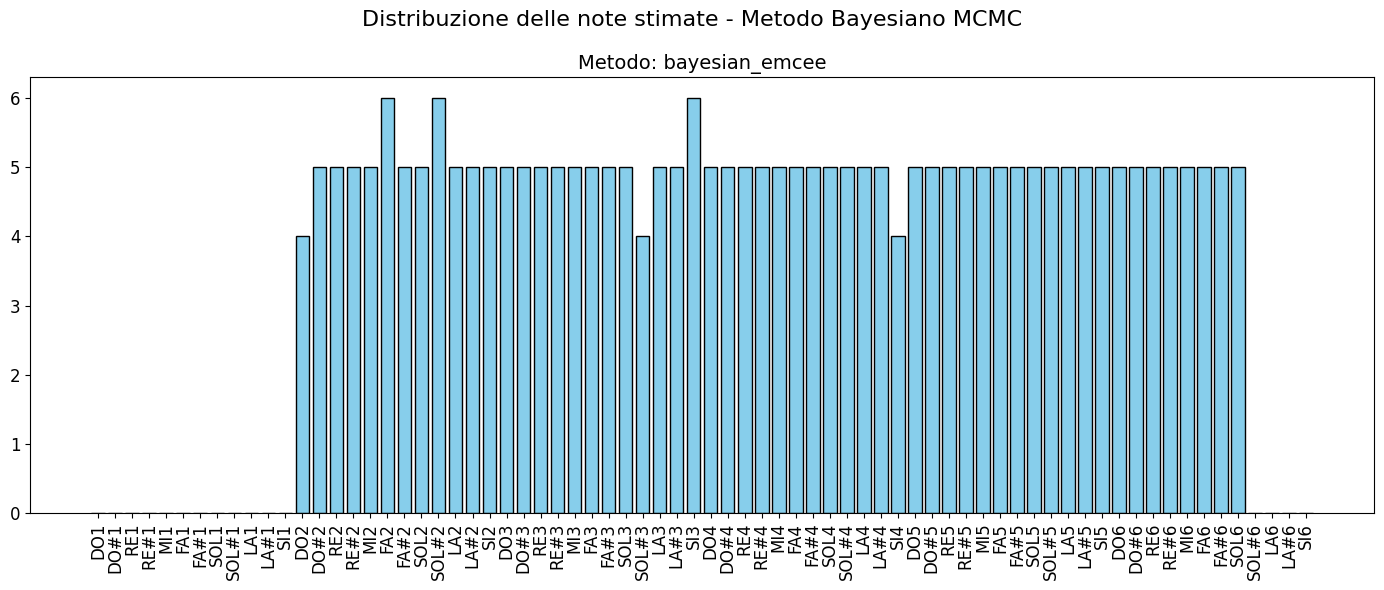

In [20]:
note_freqs = {}
for octave in range(1, 7):  # 1..8
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

print("Frequenze delle note:")
for note, freq in sorted(note_freqs.items()):
    print(f"  {note}: {freq:.2f} Hz")



# binning dei risultati nelle note più vicine
def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

binned_results = {'bayesian_emcee': []}

# 2. Iteriamo sui metodi
for method in ['bayesian_emcee']:
    
    # 3. Iteriamo sul dizionario f0_results
    # sample sarà il nome del file (es. "Nota_1")
    # methods_dict sarà il dizionario interno (es. {'bayesian_emcee': 440.0})
    for sample, methods_dict in f0_results.items():
        
        # Estraiamo la frequenza specifica per questo metodo
        freq = methods_dict.get(method)
        
        if freq is not None:
            # Per sicurezza, ci assicuriamo che sia un numero (float)
            freq_float = float(freq)
            
            # Troviamo la nota più vicina
            closest_note = find_closest_note(freq_float, note_freqs)
            
            # Salviamo il risultato nella lista corrispondente al metodo
            binned_results[method].append(closest_note)
        else:
            # Se la frequenza era None, salviamo None
            binned_results[method].append(None)

ordered_notes = list(note_freqs.keys())
method = 'bayesian_emcee'

# Creiamo una figura con 1 solo grafico e dimensioni proporzionate
fig, ax = plt.subplots(figsize=(14, 6))

fig.suptitle("Distribuzione delle note stimate - Metodo Bayesiano MCMC", fontsize=16)

# Contiamo quante volte compare ogni nota
counts = [binned_results[method].count(note) for note in ordered_notes]

# Disegniamo il grafico a barre
ax.bar(np.arange(len(ordered_notes)), counts, width=0.8, color='skyblue', edgecolor='black')
ax.set_title(f"Metodo: {method}", fontsize=14)

# Impostiamo le etichette sull'asse x
ax.set_xticks(np.arange(len(ordered_notes)))
ax.set_xticklabels(ordered_notes, rotation=90)

# Linee di riferimento
#ax.axhline(5, color='blue', linewidth=2)

#if "DO2" in ordered_notes:
#    ax.axvline(ordered_notes.index("DO2"), color='blue', linewidth=2)
#if "SOL6" in ordered_notes:
#    ax.axvline(ordered_notes.index("SOL6"), color='blue', linewidth=2)

plt.savefig("distribuzione_note_bayes_emcee.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()



